# Fatal Vs. Non-Fatal Accidents In Ottawa
Apply Machine Learning algorithms to determine the best model and hyper parameters for an imbalanced dataset
1. Import all necessary libraries
2. Load the dataset and get information
3. Test different load balancers, test splits, and models
4. Determine the best model
5. Apply hyper parameter tuning of the best model

### 1. Import all necessary libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    precision_score, recall_score, f1_score, matthews_corrcoef, accuracy_score, confusion_matrix, average_precision_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC

%pip install xgboost
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTEENN

Note: you may need to restart the kernel to use updated packages.


### 2. Load the dataset and get information

In [3]:
# Load Dataset
df = pd.read_csv('final_features (1).csv')
df.head()

,Classification_Of_Accident,num_of_vehicles,num_of_pedestrians,num_of_bicycles,num_of_motorcycles,month,day_of_week,is_weekend,season,vulnerable_users,...,Traffic_Control_ Ped. crossover,Traffic_Control_ Police control,Traffic_Control_ Roundabout,Traffic_Control_ School bus,Traffic_Control_ School guard,Traffic_Control_ Stop sign,Traffic_Control_ Traffic controller,Traffic_Control_ Traffic gate,Traffic_Control_ Traffic signal,Traffic_Control_ Yield sign
0,0,2,0,0,0,1,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,2,0,0,0,1,3,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0,1,1,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
3,0,2,0,0,0,1,2,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,0,2,0,0,0,1,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Determine the ratio of Non-Fatal to Fatal and get the DataFrame information

In [4]:
df['Classification_Of_Accident'].value_counts()

Classification_Of_Accident
0    91673
1      170
Name: count, dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91843 entries, 0 to 91842
Data columns (total 60 columns):
 #   Column                                           Non-Null Count  Dtype
---  ------                                           --------------  -----
 0   Classification_Of_Accident                       91843 non-null  int64
 1   num_of_vehicles                                  91843 non-null  int64
 2   num_of_pedestrians                               91843 non-null  int64
 3   num_of_bicycles                                  91843 non-null  int64
 4   num_of_motorcycles                               91843 non-null  int64
 5   month                                            91843 non-null  int64
 6   day_of_week                                      91843 non-null  int64
 7   is_weekend                                       91843 non-null  int64
 8   season                                           91843 non-null  int64
 9   vulnerable_users                                 9

Insights:
- Approximately 0.18% of the provided dataset is imbalanced.
- There are 91843 entries total with 60 attributes
- Based on the amount of imbalance it is best to determine the confusion matrix and get metrics for precision, recall, and f1 score
- Use Precision-Recall Curve instead of the Receive Operating Characteristic curve, as it provides better insight into minority class detection

Links:
- https://medium.com/cuenex/advanced-evaluation-metrics-for-imbalanced-classification-models-ee6f248c90ca
- https://leonidasgorgo.medium.com/understanding-roc-auc-and-pr-auc-c488faf45a16
- https://machinelearningmastery.com/roc-auc-vs-precision-recall-for-imbalanced-data/
- https://www.kaggle.com/discussions/general/253378


### 3. Test different load balancers, test splits, and models
- The original three models choosen were Logistic Regression, RandomForest, and XGBoost. K-Nearest Neighbor (KNN) and Artificial Neural Network (ANN) were choosen at first to be the other 2 models to make a total of 5. However, during testing KNN and ANN were deemed to slow. Thereby, Gradient Boosting was choosen as boosting algorithms reduce errors in each iteration. Although the Linear SVM model is not an optimal model for imbalanced datasets, it was choosen for a comparison to determine the requirements of a simple or complex model.  
- Applied dictionaries to models, balancers, and a list for test split to iterate over all possibilities in one run rather than through multiple cells
- Append each result to a dictionary to later be assigned as a DataFrame for further analysis

Links:
- https://shivamkc01.medium.com/handling-imbalanced-dataset-in-machine-learning-9ac075787e07
- https://www.ibm.com/think/topics/support-vector-machine#:~:text=They%20distinguish%20between%20two%20classes,and%20the%20specific%20use%20case.

In [32]:
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000),
    "Random Forest" : RandomForestClassifier(random_state=42),
    "XGBoost" : XGBClassifier(eval_metric='aucpr', random_state=42),
    "Gradient Boosting" : GradientBoostingClassifier(random_state=42),
    "Linear SVM" : LinearSVC(max_iter=1000, random_state=42)
}

In [7]:
balancers = [

    # SMOTE
    ("smote_default", SMOTE(random_state=42)),
    ("smote_k3", SMOTE(k_neighbors=3, random_state=42)),
    ("smote_0.1", SMOTE(sampling_strategy=0.1, random_state=42)),
    ("smote_0.1_k3", SMOTE(sampling_strategy=0.1, k_neighbors=3, random_state=42)),
    ("smote_0.05", SMOTE(sampling_strategy=0.05, random_state=42)),
    ("smote_0.05_k3", SMOTE(sampling_strategy=0.05, k_neighbors=3, random_state=42)),

    # ADASYN
    ("adasyn_default", ADASYN(random_state=42)),
    ("adasyn_k3", ADASYN(n_neighbors=3, random_state=42)),
    ("adasyn_0.1", ADASYN(sampling_strategy=0.1, random_state=42)),
    ("adasyn_0.1_k3", ADASYN(sampling_strategy=0.1, n_neighbors=3, random_state=42)),
    ("adasyn_0.05", ADASYN(sampling_strategy=0.05, random_state=42)),
    ("adasyn_0.05_k3", ADASYN(sampling_strategy=0.05, n_neighbors=3, random_state=42)),

    # SMOTEENN
    ("smoteenn_default", SMOTEENN(random_state=42)),
    ("smoteenn_k3", SMOTEENN(smote=SMOTE(k_neighbors=3), random_state=42)),
    ("smoteenn_0.1", SMOTEENN(smote=SMOTE(sampling_strategy=0.1), random_state=42)),
    ("smoteenn_0.1_k3", SMOTEENN(smote=SMOTE(sampling_strategy=0.1, k_neighbors=3), random_state=42)),
    ("smoteenn_0.05", SMOTEENN(smote=SMOTE(sampling_strategy=0.05), random_state=42)),
    ("smoteenn_0.05_k3", SMOTEENN(smote=SMOTE(sampling_strategy=0.05, k_neighbors=3), random_state=42)),
]

In [8]:
splits = [0.3, 0.2, 0.15]

In [9]:
X = df.drop('Classification_Of_Accident', axis=1)
y = df['Classification_Of_Accident']

In [10]:
results = []
predictions = {}

for split in splits:

    print(f"\nSplit: {split}")

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=split,
        random_state=42,
        stratify=y
    )

    for balancer_name, balancer in balancers:

        print(f"\nBalancer: {balancer_name}")

        try:
            X_res, y_res = balancer.fit_resample(X_train, y_train)
        except:
            continue

        for model_name, model in models.items():

            print("Training:", model_name)

            model.fit(X_res, y_res)

            test_pred = model.predict(X_test)

            if hasattr(model, "predict_proba"):
                y_prob = model.predict_proba(X_test)[:,1]
            else:
                y_prob = model.decision_function(X_test)

            precision = precision_score(y_test, test_pred, zero_division=0)
            recall = recall_score(y_test, test_pred)
            f1 = f1_score(y_test, test_pred, zero_division=0)

            mcc = matthews_corrcoef(y_test, test_pred)
            acc = accuracy_score(y_test, test_pred)

            pr_auc = average_precision_score(y_test, y_prob)

            cm = confusion_matrix(y_test, test_pred)

            tn, fp, fn, tp = cm.ravel()
            tnr = tn / (tn + fp)

            results.append({
                "Split": split,
                "Balancer": balancer_name,
                "Model": model_name,
                "Precision": precision,
                "Recall": recall,
                "F1": f1,
                "PR_AUC": pr_auc,
                "MCC": mcc,
                "Accuracy": acc,
                "TNR": tnr
            })

            predictions[(split, balancer_name, model_name)] = test_pred


Split: 0.3

Balancer: smote_default
Training: Logistic Regression
Training: Random Forest
Training: XGBoost
Training: Gradient Boosting
Training: Linear SVM

Balancer: smote_k3
Training: Logistic Regression
Training: Random Forest
Training: XGBoost
Training: Gradient Boosting
Training: Linear SVM

Balancer: smote_0.1
Training: Logistic Regression
Training: Random Forest
Training: XGBoost
Training: Gradient Boosting
Training: Linear SVM

Balancer: smote_0.1_k3
Training: Logistic Regression
Training: Random Forest
Training: XGBoost
Training: Gradient Boosting
Training: Linear SVM

Balancer: smote_0.05
Training: Logistic Regression
Training: Random Forest
Training: XGBoost
Training: Gradient Boosting
Training: Linear SVM

Balancer: smote_0.05_k3
Training: Logistic Regression
Training: Random Forest
Training: XGBoost
Training: Gradient Boosting
Training: Linear SVM

Balancer: adasyn_default
Training: Logistic Regression
Training: Random Forest
Training: XGBoost
Training: Gradient Boosting

### 4. Determine the best model

In [11]:
results_df = pd.DataFrame(results)
results_df

,Split,Balancer,Model,Precision,Recall,F1,PR_AUC,MCC,Accuracy,TNR
0,0.30,smote_default,Logistic Regression,0.009366,0.431373,0.018333,0.012897,0.053373,0.914492,0.915388
1,0.30,smote_default,Random Forest,0.008368,0.078431,0.015123,0.006169,0.020146,0.981091,0.982765
2,0.30,smote_default,XGBoost,0.006791,0.078431,0.012500,0.007654,0.016987,0.977062,0.978729
3,0.30,smote_default,Gradient Boosting,0.011693,0.529412,0.022881,0.016387,0.069252,0.916307,0.917024
4,0.30,smote_default,Linear SVM,0.008710,0.411765,0.017059,0.011061,0.049416,0.912169,0.913097
...,...,...,...,...,...,...,...,...,...,...
265,0.15,smoteenn_0.05_k3,Logistic Regression,0.047619,0.038462,0.042553,0.024117,0.041170,0.996734,0.998546
266,0.15,smoteenn_0.05_k3,Random Forest,0.027027,0.038462,0.031746,0.008948,0.030059,0.995572,0.997382
267,0.15,smoteenn_0.05_k3,XGBoost,0.037037,0.038462,0.037736,0.016946,0.035888,0.996298,0.998109
268,0.15,smoteenn_0.05_k3,Gradient Boosting,0.034483,0.038462,0.036364,0.029569,0.034494,0.996153,0.997964


- Use Matthew Correlation Coefficient (MCC) as a measure to determine the best model, as MCC takes the imbalance of the dataset into account when calculating
- Get the top 5 results
- Graph the Precision-Recall AUC of the top 5 results

Links:
- https://medium.com/@anishnama20/matthews-correlation-coefficient-mcc-one-of-the-best-metric-when-2-classes-are-imbalanced-c0318ac68c21


In [17]:
results_sorted = results_df.sort_values("MCC", ascending=False)
top5 = results_sorted.head()
top5

,Split,Balancer,Model,Precision,Recall,F1,PR_AUC,MCC,Accuracy,TNR
198,0.15,smote_0.1_k3,Gradient Boosting,0.070175,0.153846,0.096386,0.028249,0.101416,0.994556,0.996146
18,0.30,smote_0.1_k3,Gradient Boosting,0.064000,0.156863,0.090909,0.020935,0.097610,0.994193,0.995746
108,0.20,smote_0.1_k3,Gradient Boosting,0.059701,0.117647,0.079208,0.018939,0.081433,0.994937,0.996564
172,0.20,smoteenn_0.05,XGBoost,0.076923,0.088235,0.082192,0.016624,0.080563,0.996353,0.998037
78,0.30,smoteenn_0.1_k3,Gradient Boosting,0.066667,0.098039,0.079365,0.021780,0.078781,0.995790,0.997455


- Uses the appropriate balancer and parameters associated based on the previously defined dictionary
- The process involves splitting the data and fitting the models again to properly graph the curve, instead of using the average Precision-Recall value from the DataFrame to graph a bar chart

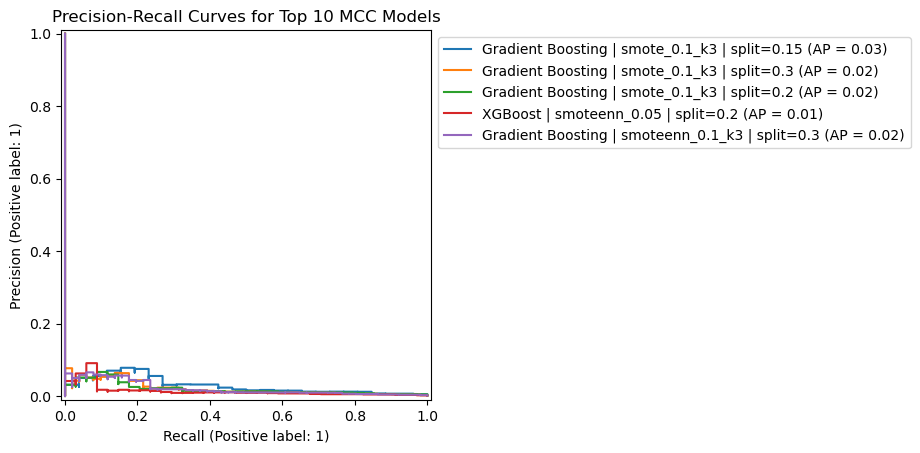

In [22]:
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots()

for i in range(len(top5)):

    model_name = top5.iloc[i]["Model"]
    balancer_name = top5.iloc[i]["Balancer"]
    split = top5.iloc[i]["Split"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=split,
        random_state=42,
        stratify=y
    )
    
    model = models[model_name]
    balancer = dict(balancers)[balancer_name]

    X_res, y_res = balancer.fit_resample(X_train, y_train)

    model.fit(X_res, y_res)

    label = model_name + " | " + balancer_name + " | split=" + str(split)

    PrecisionRecallDisplay.from_estimator(
        model,
        X_test,
        y_test,
        ax=ax,
        name=label
    )

plt.title("Precision-Recall Curves for Top 10 MCC Models")
ax.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.show()

- Get a summary of the top 5 models to compare the best model output versus the best average model parameters
- Determined based on the best metrics (MCC and PR AUC)

In [23]:
best_mcc = results_df.loc[results_df["MCC"].idxmax()]
best_mcc

Split                     0.15
Balancer          smote_0.1_k3
Model        Gradient Boosting
Precision             0.070175
Recall                0.153846
F1                    0.096386
PR_AUC                0.028249
MCC                   0.101416
Accuracy              0.994556
TNR                   0.996146
Name: 198, dtype: object

In [24]:
best_pr_auc = results_df.loc[results_df["PR_AUC"].idxmax()]
best_pr_auc

Split                     0.15
Balancer           adasyn_0.05
Model        Gradient Boosting
Precision                  0.0
Recall                     0.0
F1                         0.0
PR_AUC                0.036524
MCC                  -0.001336
Accuracy              0.997169
TNR                   0.999055
Name: 233, dtype: object

### 5. Apply hyper parameter tuning of the best model
- The top model and highest average model was both SMOTE with a sampling_strategy of 0.1 and k_neighbors of 3
- Use StratifiedKFold as the cross validation as it preserves the percentage of samples for each class
- Apply the best balancer parameters
- Create a param_grid dictionary for GridSearchCV, although it is computationally expensive, it is very reliable
- The parameters choosen were very basic

Links:
- https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html
- https://medium.com/@fraidoonomarzai99/hyperparameters-tunning-and-cross-validation-in-depth-d0918b62d986


In [25]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [26]:
best_balancer = SMOTE(
    sampling_strategy=0.1,
    random_state=42,
    k_neighbors=3
)

In [29]:
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3],
    "min_samples_split": [2, 5],
    "subsample": [0.8, 1.0]
}

In [ ]:
X_res, y_res = best_balancer.fit_resample(X_train, y_train)
model = GradientBoostingClassifier(random_state=42)

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
    verbose=2
)

grid.fit(X_res, y_res)

print("Best Parameters:")
print(grid.best_params_)

# print("Best CV Score (PR-AUC):")
# print(grid.best_score_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 200, 'subsample': 0.8}


In [37]:
best_model = grid.best_estimator_

best_model.fit(X_res, y_res)

GradientBoostingClassifier(n_estimators=200, random_state=42, subsample=0.8)

- In comparison to the best parameters and to the estimator the parameters remained the same.
- It only displays n_estimators, random_state, and subsample as those were "changed", as learning_rate, max_depth, and min_samples_split for the best parameters are the default
- Therefore, the best parameters and the best estimator are the same and can be used for testing

In [38]:
# Evaluate on test set
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
pr_auc = average_precision_score(y_test, y_prob)
mcc = matthews_corrcoef(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
tnr = tn/(tn+fp)

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("PR-AUC:", pr_auc)
print("MCC:", mcc)
print("TNR:", tnr)
print("CM: \n", cm)

Precision: 0.03488372093023256
Recall: 0.058823529411764705
F1: 0.043795620437956206
PR-AUC: 0.015212735548008527
MCC: 0.043002124598426096
TNR: 0.9969820376699876
CM: 
 [[27419    83]
 [   48     3]]


- Based on the results above, the model struggles to detect the minority class (Fatal), however, based on the True Negative Rate (TNR) the model is highly effective in identifying negative cases